```Instagram Influencers Analysis – Data Cleaning, Preprocessing & Exploratory Data Analysis```

```Description```

* This project presents a comprehensive Exploratory Data Analysis (EDA) of a dataset containing top Instagram influencers. The dataset includes key performance indicators such as ranking, influence score, follower count, number of posts, average likes, engagement rate, total likes, country, and joining date.

* The analysis began with data cleaning and preprocessing, including handling missing values, converting data types (such as numerical and date formats), and transforming textual metrics (k, m, b) into standardized numerical values for accurate analysis.

* Further, univariate analysis was conducted to understand the distribution of influence scores, engagement rates, followers, and posting activity using histograms and descriptive statistics.

* Next, bivariate and correlation analysis was performed using heatmaps to identify relationships between influence score, followers, engagement rate, and average likes. This helped determine the key drivers of influencer performance.

* Additionally, country-wise analysis was conducted to identify geographic distribution and top contributing countries in the influencer ecosystem.

* Overall, this project focuses on extracting meaningful business insights from social media performance data through structured data exploration and visualization techniques.

In [103]:
# load the required library 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import warnings
warnings.filterwarnings('ignore')

In [104]:
# create a connection 
conn = psycopg2.connect(
    host="localhost",
    database="internproject",   
    user="postgres",       
    password="Yusufrazakhan12@", 
    port="5432"
)

In [188]:
# see the data present in the table 
tables = pd.read_sql_query(
    "SELECT table_name FROM information_schema.tables WHERE table_schema = 'public'",
    conn)
tables

,table_name
0,supermart_grocery_sales
1,tcs_cleaned_data
2,googleplaystore
3,netflix1
4,netflix_clean
5,tcs_stock_history
6,top_insta_influencers_


### Load the dataset

In [189]:
# fetch the data
data = pd.read_sql('SELECT * FROM "top_insta_influencers_";', conn)
data.head(5)

,rank,channel_info,influence_score,influence_category,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,country,joining_date
0,1,instagram,50,High,8.31k,698m,327k,0.05%,327k,2.72b,United States,Feb-12
1,2,cristiano,61,High,4.0k,670m,8.7m,1.30%,6.5m,34.80b,Portugal,May-12
2,3,leomessi,47,High,1.45k,511m,6.8m,1.33%,4.4m,9.86b,Spain,Jun-13
3,4,selenagomez,40,Medium,2.15k,415m,6.2m,1.49%,3.3m,13.33b,United States,Jul-13
4,5,kyliejenner,42,Medium,7.36k,391m,8.3m,2.12%,2.4m,61.09b,United States,Nov-11


### Data cleaning and preprocessing

In [191]:
# data head
data.head(5)

,rank,channel_info,influence_score,influence_category,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,country,joining_date
0,1,instagram,50,High,8.31k,698m,327k,0.05%,327k,2.72b,United States,Feb-12
1,2,cristiano,61,High,4.0k,670m,8.7m,1.30%,6.5m,34.80b,Portugal,May-12
2,3,leomessi,47,High,1.45k,511m,6.8m,1.33%,4.4m,9.86b,Spain,Jun-13
3,4,selenagomez,40,Medium,2.15k,415m,6.2m,1.49%,3.3m,13.33b,United States,Jul-13
4,5,kyliejenner,42,Medium,7.36k,391m,8.3m,2.12%,2.4m,61.09b,United States,Nov-11


In [193]:
# check data rows and column 
data.shape

(200, 12)

In [194]:
# data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   rank                200 non-null    int64 
 1   channel_info        200 non-null    object
 2   influence_score     200 non-null    int64 
 3   influence_category  200 non-null    object
 4   posts               200 non-null    object
 5   followers           200 non-null    object
 6   avg_likes           200 non-null    object
 7   engagement_rate     200 non-null    object
 8   new_post_avg_like   200 non-null    object
 9   total_likes         200 non-null    object
 10  country             200 non-null    object
 11  joining_date        200 non-null    object
dtypes: int64(2), object(10)
memory usage: 18.9+ KB


In [195]:
# drop duplicate if present  
data.drop_duplicates(inplace=True)

In [196]:
# Again check shape 
data.shape
print(f"There is no duplicate data in the data set ",data.shape)

There is no duplicate data in the data set  (200, 12)


In [197]:
# check null values
data.isnull().sum()

rank                  0
channel_info          0
influence_score       0
influence_category    0
posts                 0
followers             0
avg_likes             0
engagement_rate       0
new_post_avg_like     0
total_likes           0
country               0
joining_date          0
dtype: int64

``` There is no Null value the data is totally cleaned ```

In [198]:
# convert date column from object to date_time
data[['joining_date']].head(5)

,joining_date
0,Feb-12
1,May-12
2,Jun-13
3,Jul-13
4,Nov-11


In [199]:
# Convert joining_date into datetime data type
data['joining_date'] = pd.to_datetime(data['joining_date'], format='%b-%y')

In [200]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   rank                200 non-null    int64         
 1   channel_info        200 non-null    object        
 2   influence_score     200 non-null    int64         
 3   influence_category  200 non-null    object        
 4   posts               200 non-null    object        
 5   followers           200 non-null    object        
 6   avg_likes           200 non-null    object        
 7   engagement_rate     200 non-null    object        
 8   new_post_avg_like   200 non-null    object        
 9   total_likes         200 non-null    object        
 10  country             200 non-null    object        
 11  joining_date        200 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 18.9+ KB


In [201]:
data.head()

,rank,channel_info,influence_score,influence_category,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,country,joining_date
0,1,instagram,50,High,8.31k,698m,327k,0.05%,327k,2.72b,United States,2012-02-01
1,2,cristiano,61,High,4.0k,670m,8.7m,1.30%,6.5m,34.80b,Portugal,2012-05-01
2,3,leomessi,47,High,1.45k,511m,6.8m,1.33%,4.4m,9.86b,Spain,2013-06-01
3,4,selenagomez,40,Medium,2.15k,415m,6.2m,1.49%,3.3m,13.33b,United States,2013-07-01
4,5,kyliejenner,42,Medium,7.36k,391m,8.3m,2.12%,2.4m,61.09b,United States,2011-11-01


In [202]:
# select the column where we have to make changes 
convert_column = ['total_likes', 'posts', 'followers','avg_likes', 'engagement_rate', 'new_post_avg_like']

# value replace with another value 
replace = {'b': 'e9', 'm': 'e6', 'k': 'e3', '%': ''}

data[convert_column] = data[convert_column].replace(replace,regex=True).astype(float)
data[convert_column]

,total_likes,posts,followers,avg_likes,engagement_rate,new_post_avg_like
0,2.720000e+09,8310.0,698000000.0,327000.0,0.05,327000.0
1,3.480000e+10,4000.0,670000000.0,8700000.0,1.30,6500000.0
2,9.860000e+09,1450.0,511000000.0,6800000.0,1.33,4400000.0
3,1.333000e+10,2150.0,415000000.0,6200000.0,1.49,3300000.0
4,6.109000e+10,7360.0,391000000.0,8300000.0,2.12,2400000.0
...,...,...,...,...,...,...
195,6.000000e+07,433.0,34100000.0,136200.0,0.40,66800.0
196,1.390000e+09,5240.0,34100000.0,264700.0,0.78,209200.0
197,3.500000e+08,320.0,34000000.0,1100000.0,3.24,210400.0
198,2.740000e+09,1370.0,29800000.0,2000000.0,6.71,1200000.0


In [218]:
# Again check data type 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rank                 200 non-null    int64  
 1   channel_info         200 non-null    object 
 2   influence_score      200 non-null    int64  
 3   influence_category   200 non-null    object 
 4   posts                200 non-null    float64
 5   followers            200 non-null    float64
 6   avg_likes            200 non-null    float64
 7   engagement_rate      200 non-null    float64
 8   new_post_avg_like    200 non-null    float64
 9   total_likes          200 non-null    float64
 10  country              200 non-null    object 
 11  joining_year         200 non-null    int32  
 12  joining_month_name   200 non-null    object 
 13  like_follower_ratio  200 non-null    float64
 14  post_follower_ratio  200 non-null    float64
dtypes: float64(8), int32(1), int64(2), objec

### EDA (Expolatory Data Analysis)

```1 Summary Statistics```

In [102]:
data.describe()

,rank,influence_score,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes
count,200.000000,200.00000,200.000000,2.000000e+02,2.000000e+02,200.000000,2.000000e+02,2.000000e+02
mean,100.500000,12.70500,6243.855000,9.302650e+07,1.894552e+06,2.637350,2.180771e+06,4.866300e+09
std,57.879185,11.93104,13705.857612,1.010048e+08,2.721125e+06,4.507993,1.807999e+07,7.707045e+09
min,1.000000,3.00000,2.000000,2.910000e+07,1.200000e+03,0.000000,2.400000e+03,0.000000e+00
25%,50.750000,6.00000,1062.500000,4.490000e+07,4.970000e+05,0.797500,1.895500e+05,1.110000e+09
50%,100.500000,8.50000,2210.000000,5.695000e+07,1.100000e+06,1.530000,4.331000e+05,2.380000e+09
75%,150.250000,15.00000,5630.000000,8.032500e+07,2.100000e+06,2.695000,1.100000e+06,4.522500e+09
max,200.000000,95.00000,125000.000000,6.980000e+08,2.430000e+07,43.550000,2.560000e+08,6.109000e+10


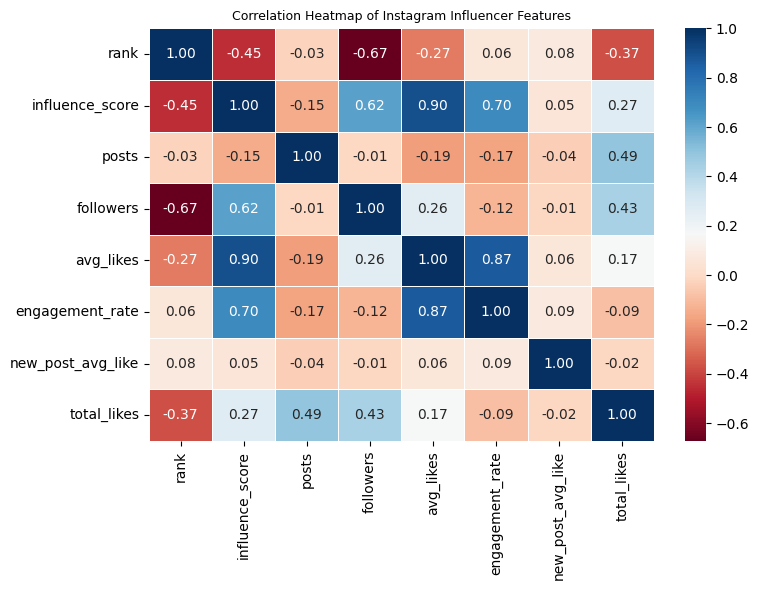

In [138]:
# Correlation Of Features
num_col = data.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8, 6))
sns.heatmap(num_col.corr(), annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Instagram Influencer Features', fontsize=9)
plt.tight_layout()
plt.show()

``` Insights```

* Influence score mainly depends on average likes (90% strong relationship) and engagement rate (70% strong relationship).

* Followers strongly affect ranking (67% relationship), meaning more followers usually mean better rank.

* Average likes and engagement rate are very closely connected (87%), so higher likes increase engagement.

* Number of posts has very low impact (only 15–17%), so posting more does not guarantee success.

* Total likes show moderate growth connection with posts (49%) and followers (43%), meaning consistency helps over time.

``` 2 Top Contries By Influencer ```

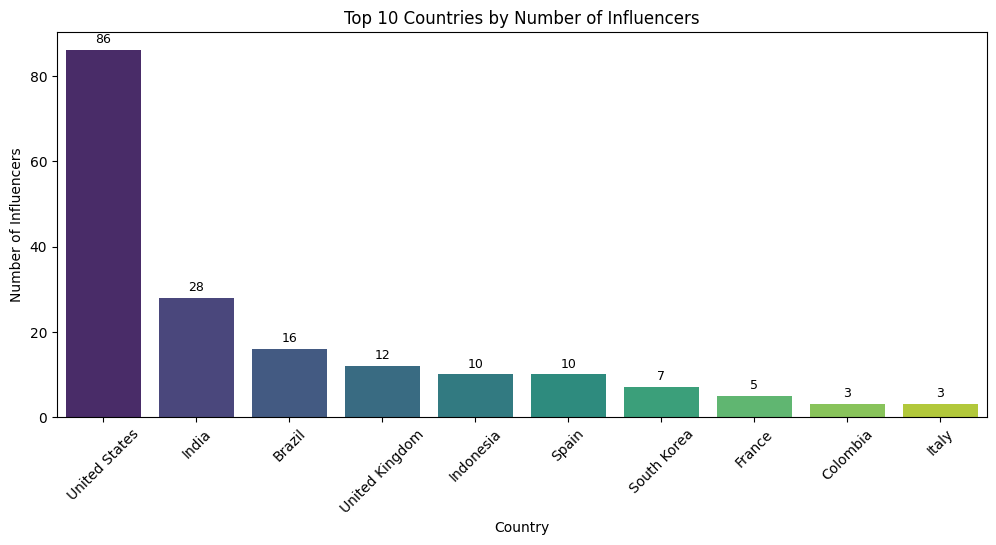

In [139]:
top_countries = data['country'].value_counts().head(10)

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=top_countries.index, y=top_countries.values, palette="viridis")

# add labels on bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
    
plt.title('Top 10 Countries by Number of Influencers')
plt.xlabel('Country')
plt.ylabel('Number of Influencers')
plt.xticks(rotation=45)
plt.show()

```Insights```

* The United States dominates the influencer landscape with 86 influencers, significantly higher than any other country.

* India ranks second (28 influencers), showing strong growth potential in the influencer marketing industry.

* Brazil (16) and the United Kingdom (12) contribute moderately, indicating active but smaller influencer markets.

* Countries like Indonesia and Spain (10 each) show emerging influencer ecosystems.

* France, Colombia, and Italy have relatively low representation (3–5 influencers), suggesting limited presence in the top-tier influencer segment* 

``` 03 Filtering influencers with over 1 million followers```

In [207]:
# Filtering influencers with over 1 million followers
high_followers = data[data['followers'] > 1_000_000]
high_followers.head(10)

,rank,channel_info,influence_score,influence_category,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,country,joining_date
0,1,instagram,50,High,8310.0,698000000.0,327000.0,0.05,327000.0,2.720000e+09,United States,2012-02-01
1,2,cristiano,61,High,4000.0,670000000.0,8700000.0,1.30,6500000.0,3.480000e+10,Portugal,2012-05-01
2,3,leomessi,47,High,1450.0,511000000.0,6800000.0,1.33,4400000.0,9.860000e+09,Spain,2013-06-01
3,4,selenagomez,40,Medium,2150.0,415000000.0,6200000.0,1.49,3300000.0,1.333000e+10,United States,2013-07-01
4,5,kyliejenner,42,Medium,7360.0,391000000.0,8300000.0,2.12,2400000.0,6.109000e+10,United States,2011-11-01
5,6,therock,31,Medium,8280.0,390000000.0,1900000.0,0.49,665300.0,1.573000e+10,United States,2012-10-01
6,7,arianagrande,33,Medium,480.0,372000000.0,3700000.0,0.99,1500000.0,1.780000e+09,United States,2011-08-01
7,8,kimkardashian,31,Medium,6580.0,353000000.0,3500000.0,0.99,2900000.0,2.303000e+10,United States,2012-01-01
8,9,beyonce,28,Medium,2430.0,308000000.0,3600000.0,1.17,820000.0,8.750000e+09,United States,2012-11-01
9,10,khloekardashian,26,Medium,4780.0,299000000.0,2400000.0,0.80,926900.0,1.147000e+10,United States,2012-08-01


```04 Filtering influencers with an engagement rate above 5%```

In [209]:
# Filtering influencers with an engagement rate above 5%
high_engagement = data[data['engagement_rate'] > 5]
high_engagement.head(10)

,rank,channel_info,influence_score,influence_category,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,country,joining_date
33,34,billieeilish,29,Medium,1030.0,125000000.0,8500000.0,6.80,2200000.0,8.760000e+09,United States,2012-03-01
34,35,lalalalisa_m,23,Low,1190.0,106000000.0,5800000.0,5.47,3200000.0,6.900000e+09,United States,2018-06-01
48,49,roses_are_rosie,19,Low,1180.0,84300000.0,4600000.0,5.46,3100000.0,5.430000e+09,United States,2018-06-01
50,51,sooyaaa__,19,Low,1290.0,80300000.0,4500000.0,5.60,2100000.0,5.810000e+09,South Korea,2018-06-01
55,56,bts.bighitofficial,18,Low,1200.0,78000000.0,4100000.0,5.26,3600000.0,4.920000e+09,South Korea,2015-11-01
62,63,milliebobbybrown,18,Low,710.0,72300000.0,4000000.0,5.53,1900000.0,2.840000e+09,United States,2016-06-01
67,68,thv,55,High,150.0,70100000.0,15400000.0,21.97,7000000.0,2.310000e+09,South Korea,2021-12-01
81,82,tomholland2013,23,Low,1300.0,62900000.0,5200000.0,8.27,2200000.0,6.760000e+09,United Kingdom,2012-05-01
88,89,travisscott,15,Low,3340.0,59900000.0,3000000.0,5.01,2600000.0,1.002000e+10,United States,2012-01-01
95,96,adele,21,Low,500.0,57600000.0,4700000.0,8.16,1900000.0,2.350000e+09,United Kingdom,2015-10-01


```05 Relation b/w followers and Engagement rate```

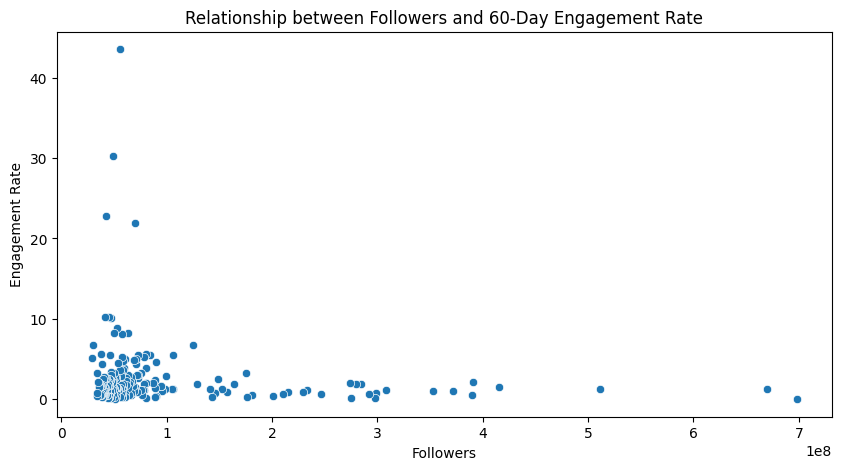

In [210]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='followers', y='engagement_rate',data=data)

# label and title 
plt.title('Relationship between Followers and 60-Day Engagement Rate')
plt.xlabel('Followers')
plt.ylabel('Engagement Rate')
plt.show()


```2. Distribution of Influence Score```

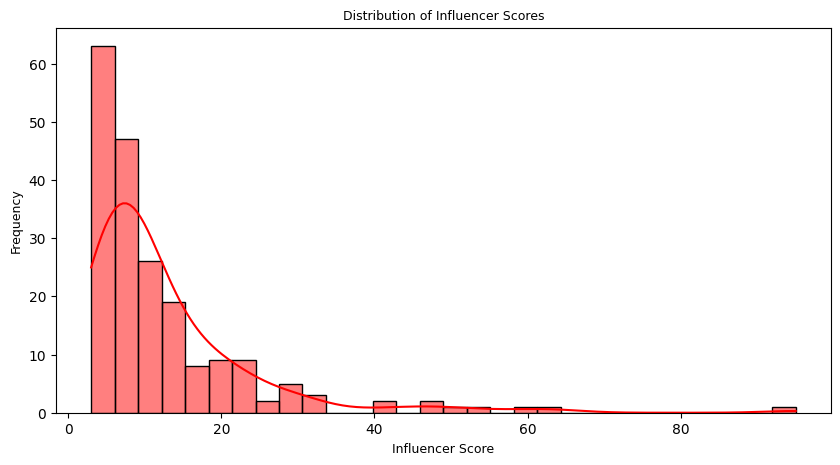

In [158]:
plt.figure(figsize=(10, 5))
sns.histplot(data['influence_score'], kde=True,color='red')

# label and title
plt.title('Distribution of Influencer Scores', fontsize = 9)
plt.xlabel('Influencer Score',fontsize = 9)
plt.ylabel('Frequency',fontsize = 9)
plt.show()

``` Insight ```

* Most influencers have low to medium scores (mainly between 5 and 15).

* Only a few influencers have very high scores, which creates a right-side long tail in the graph.

* The graph is right-skewed, meaning high performers are limited in number.

* There is a big gap between average influencers and top influencers.

* Overall, influence is not evenly distributed — a small group holds very high influence.

 ### Feature Engineering

In [211]:
# Now extract Month and year from the data set 
data['joining_month_name'] = data['joining_date'].dt.month_name()  # February
data['joining_year'] = data['joining_date'].dt.year          # 2012

In [212]:
# Creating engagement-related features
data['like_follower_ratio'] = data['total_likes'] / data['followers']
data['post_follower_ratio'] = data['posts'] / data['followers']
data['avg_likes_ratio'] = data['avg_likes'] / data['followers']

In [213]:
data.columns

Index(['rank', 'channel_info', 'influence_score', 'influence_category',
       'posts', 'followers', 'avg_likes', 'engagement_rate',
       'new_post_avg_like', 'total_likes', 'country', 'joining_date',
       'joining_month_name', 'joining_year', 'like_follower_ratio',
       'post_follower_ratio', 'avg_likes_ratio'],
      dtype='object')

In [216]:
# Now create features 
features = ['rank', 'channel_info', 'influence_score', 'influence_category', 'posts',
            'followers', 'avg_likes', 'engagement_rate', 'new_post_avg_like',
            'total_likes', 'country', 'joining_year','joining_month_name', 'like_follower_ratio',
            'post_follower_ratio']

In [217]:
# Save the cleaned dataset for Tableau / Power BI

data = data[features]

data.to_csv('top_insta_infl_cleaned_data.csv', index=False)

print("Dataset saved successfully")

Dataset saved successfully
